# Remote Sensing Data & Methods  


<br>
<font size="6"> <b> Landsat 9 <b> </font>

<font size="4"> <b> DNs to Reflectance Conversion<font color='rgba(200,0,0,0.2)'> </font> </b> </font>

<br> <img src="Figs/logo.png" width="250" align="right" /> <br> 
<font size="4"> <b> Dr. M. Adnan Siddique, and Ehtasham Naseer</b> 
<font size="3">  <br>
<font> <b> May 11, 2026 </b></font>
</font>



### Reflectance

Reflectance is the ratio of the reflected radiation from a surface to the incoming radiation (irradiance) incident upon that surface. 
It is a unitless quantity, typically expressed as a percentage or a value between 0 and 1.

Note: Reflectance is a surface property and is crucial for identifying materials, as different materials reflect light differently at various wavelengths. In many ways, we prefer to work with **reflectance** rather than spectral **radiance**, given its direct dependence on the material properies, and in an ideal sense, its independence from the illumination conditions (under uniform conditions). In that sense, it is purely a function of the material's properties and surface geometry.

## Preliminaries

### Activate Conda environment

If you set up the conda environment named `rsdm` previously, please activate it now:

```bash
conda activate rsdm
```

Installing the libraries `rioaxrray`: (if you have not installed already)

# Part I

### Setting up local directory

In [1]:
import os

# change directory to desired local directory on your machine
rootDirectory = "/home/wasif/sds/sds/landsat"
os.chdir(rootDirectory)

# relative path to data folder
dataDirectory = os.path.join(rootDirectory, "LC09_L1TP_150038_20240803_20240803_02_T1/LC09_L1TP_150038_20240803_20240803_02_T1/")

### Landsat 9 image

In [2]:
# Band # 4 (Red) of the Landsat scene, acquired on August 3, 2024
band = 4 # for dynamically setting the band
image_L1_filename = os.path.join(dataDirectory, f"LC09_L1TP_150038_20240803_20240803_02_T1_B{band}.TIF")

Level-1 data products consist of quantized and calibrated scaled Digital Numbers (DN) representing the multispectral image data.  Landsat 8 and Landsat 9 data are delivered in 16-bit unsigned integer format. Landsat 1-7 products are delivered in 8-bit unsigned integer format. Landsat Level-1 data can be converted to TOA spectral radiance, reflective band DN’s can be converted to TOA reflectance, and thermal band data can be converted from spectral radiance to TOA  brightness temperature.
[Read more here](https://www.usgs.gov/landsat-missions/using-usgs-landsat-level-1-data-product). 

## Computing Reflectance

### Convert 16-bit DNs to Reflectance

Reflective band DN’s can be converted to TOA reflectance using the rescaling coefficients in the MTL file:  

where:

$$ \rho_{λ}^{'} = M_{\rho} Q_{cal } + A_{\rho}$$

- $\rho_{λ}^{'}$ = TOA planetary reflectance, without correction for solar angle.
- $M_{\rho}$ = Band-specific multiplicative rescaling factor from the metadata (`REFLECTANCE_MULT_BAND_x`, where x is the band number)
- $A_{\rho}$= Band-specific additive rescaling factor from the metadata (`REFLECTANCE_ADD_BAND_x`, where x is the band number)
- $Q_{cal }$ =  Quantized and calibrated standard product pixel values (`DN`)         

TOA reflectance with a correction for the sun angle is then:

$$\rho_{λ} = \dfrac{\rho_{λ}^{'}}{\sin(\theta_{SE})} = \dfrac{\rho_{λ}^{'}}{\cos(\theta_{SZ})}$$

where

where:

- $\rho_{λ}$ =  TOA planetary reflectance
- $\theta_{SE}$ =  Local sun elevation angle. The scene center sun elevation angle in degrees is provided in the metadata (`SUN_ELEVATION`).
- $\theta_{SZ}$ = Local solar zenith angle;  $\theta_{SZ} = 90° - \theta_{SE}$




The scaling factors are available in the metadata file: `LC09_L1TP_150038_20240803_20240803_02_T1_MTL.txt`.

In [9]:
Landsat9_mtt_dict = {}

# Reading in the metadata
metadata_filename = os.path.join(dataDirectory, "LC09_L1TP_150038_20240803_20240803_02_T1_MTL.txt")
with open(metadata_filename, 'r') as _:
    for line in _:
        line = line.strip()
        if line != 'END':
            key, value = line.split('=')
            key = key.rstrip()
            Landsat9_mtt_dict[key] = value

key = None
value = None

Accessing scaling factors from the metadata

In [10]:
# read and print multiplicative, additive factors, and sun_angle values for band 4 i.e. REFLECTANCE_MULT_BAND_4, REFLECTANCE_ADD_BAND_4, SUN_ELEVATION
mult = Landsat9_mtt_dict['REFLECTANCE_MULT_BAND_4']
add = Landsat9_mtt_dict['REFLECTANCE_ADD_BAND_4']
sun_elev = Landsat9_mtt_dict['SUN_ELEVATION']

print(f"Multiplicative factor: {mult}")
print(f"Additive factor: {add}")
print(f"Sun elevation: {sun_elev}")

Multiplicative factor:  2.0000E-05
Additive factor:  -0.100000
Sun elevation:  64.33718005


Reading in the image:

In [5]:
image_L1_filename

'/home/wasif/sds/sds/landsat/LC09_L1TP_150038_20240803_20240803_02_T1/LC09_L1TP_150038_20240803_20240803_02_T1/LC09_L1TP_150038_20240803_20240803_02_T1_B4.TIF'

In [3]:
import rioxarray
dn_image = rioxarray.open_rasterio(image_L1_filename)
dn_image.head()

<xarray.DataArray (band: 1, y: 5, x: 5)> Size: 50B
[25 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 40B 3.633e+06 3.633e+06 ... 3.633e+06 3.633e+06
  * x            (x) float64 40B 1.44e+05 1.44e+05 1.441e+05 1.441e+05 1.441e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

Converting string variables to float values:

In [11]:
import numpy as np
#---> your code

m_lambda = float(mult)
a_lambda = float(add)
sun_angle_deg = float(sun_elev)

#--> compute sun zenith angle by using sun elevation angle and convert it to radians
sun_zenith_angle_rad = np.radians(90 - sun_angle_deg)
print(f"The sun zenith angle is {sun_zenith_angle_rad:0.2f} radians.")

The sun zenith angle is 0.45 radians.


Checking no data value:

In [4]:
# Access the no data value
no_data_value = dn_image.rio.nodata
print(f"Current no data value: {no_data_value}")

Current no data value: 0


Calculation for conversion of DNs to relectance:

In [9]:
reflectance_b4 = (m_lambda * dn_image + a_lambda)

# apply sun angle correction 
reflectance_b4 = reflectance_b4 / np.cos(sun_zenith_angle_rad)

Plotting the two rasters:

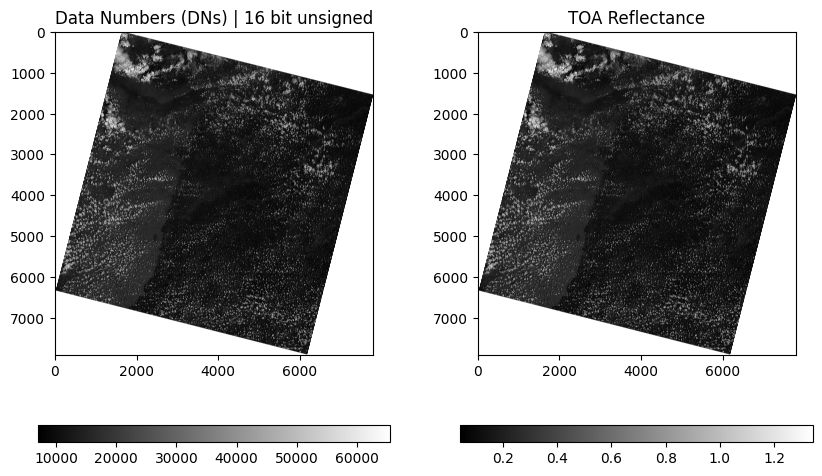

In [13]:
import matplotlib.pyplot as plt

no_data_mask = (dn_image == no_data_value)

plt.figure('GMT vs TIFF', figsize=(10, 6))
plt.subplot(1,2,1)
im1 = plt.imshow(dn_image.sel(band = 1).where(~no_data_mask), cmap='gray')
ax1 = im1.axes
ax1.set_title('Data Numbers (DNs) | 16 bit unsigned')
plt.colorbar(im1, orientation='horizontal')

plt.subplot(1,2,2)
im2 = plt.imshow(reflectance_b4.sel(band=1).where(~no_data_mask), cmap='gray')
ax2 = im2.axes
ax2.set_title('TOA Reflectance')
plt.colorbar(im2, orientation='horizontal')
plt.show()

<div class="alert alert-dark">
<font size="5"> <b> Question <b> </font>
</div>

:question: Look at the scale on the colorbar and note the different in the range of data values for both rasters. Comment

The DN raster values are in range 0-65535 (16-bit), while reflectance is 0 to 1 (or slightly higher). The colorbar ranges are different because reflectance is the normalized, calibrated version of DN.

:question: Why is the colorbar for reflectance image extending to > 1 values? Please comment, and if it is a problem, suggest a way to correct it.


Reflectance > 1 can happen because the sun angle correction divides by a small cosine value (when sun is low), which amplifies the reflectance. Also, bright surfaces or calibration effects can push it over 1. To fix it, you can clip values to [0, 1] for display.

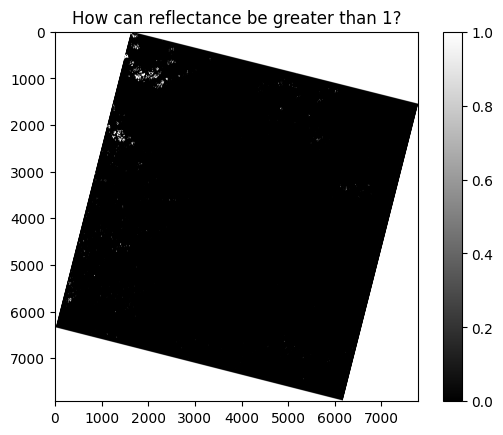

In [14]:
# Create a mask of values greater than 1
ref_gt1_data_mask = reflectance_b4.sel(band=1) > 1

# Plot the no data mask
plt.imshow(ref_gt1_data_mask.where(~no_data_mask), cmap='gray')
plt.title('How can reflectance be greater than 1?')
plt.colorbar(orientation='vertical')
plt.show()

# Part II

### Improved correction with pixel-wise sun angles

The following steps are based on the instructions availalbe from NASA, at this [link](https://www.usgs.gov/landsat-missions/solar-illumination-and-sensor-viewing-angle-coefficient-files).

Using the tool provided by NASA for computing sun and satellite zenith & azimuth angles:

In [12]:
current_path = os.getcwd()
path_to_tool = os.path.join(rootDirectory, "l8_angles")
os.chdir(path_to_tool)

The file we need next is `LC09_L1TP_150038_20240803_20240803_02_T1_solar_B04.img`. 

For details on the input/output of the ./l8_angles function call, please refer to this [article](https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/atoms/files/L8_AngleBands_README-20190503.txt) from NASA.

In [5]:
solar_angles_filename = os.path.join(rootDirectory, "l8_angles/l8_angles/LC09_L1TP_150038_20240803_20240803_02_T1_solar_B04.img")
solar_angles = rioxarray.open_rasterio(solar_angles_filename)
solar_angles.head()

<xarray.DataArray (band: 2, y: 5, x: 5)> Size: 100B
[50 values with dtype=int16]
Coordinates:
  * band         (band) int64 16B 1 2
  * y            (y) float64 40B 3.633e+06 3.633e+06 ... 3.633e+06 3.633e+06
  * x            (x) float64 40B 1.44e+05 1.44e+05 1.441e+05 1.441e+05 1.441e+05
    spatial_ref  int64 8B 0
Attributes: (12/17)
    Band_1:         Azimuth
    Band_2:         Zenith
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Azimuth', 'Zenith')
    description:     Sun Angle Band File 
    ...             ...
    data_type:      2
    interleave:     bsq
    byte_order:     0
    x_start:        0
    y_start:        0
    band_names:     Azimuth, Zenith

Please note from the print out of the `solar_angles` (an `xarray.DataArray`) that:
- there are two bands; the first is "Azimuth" (angles) and the second is "Zenith" (angles)
- the data type is uint16 

In [17]:
print(f"The coordinate reference system of the solar angles data is: {solar_angles.rio.crs}")

The coordinate reference system of the solar angles data is: EPSG:32643


In [12]:
solar_zenith_angle = solar_angles.sel(band=2)/100
solar_zenith_angle = solar_zenith_angle.where(solar_zenith_angle != no_data_value, np.nan)
solar_zenith_angle.attrs['no_data_value'] = np.nan

:question: Why are we scaling by a factor of 1/100?

The angles file stores values as integers in hundredths of a degree (e.g., 5000 = 50.00 degrees). Dividing by 100 converts them back to actual degrees.

In [19]:
solar_zenith_angle

<xarray.DataArray (y: 7921, x: 7791)> Size: 494MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(7921, 7791))
Coordinates:
  * y            (y) float64 63kB 3.633e+06 3.633e+06 ... 3.395e+06 3.395e+06
  * x            (x) float64 62kB 1.44e+05 1.44e+05 ... 3.777e+05 3.777e+05
    band         int64 8B 2
    spatial_ref  int64 8B 0
Attributes: (12/18)
    Band_1:         Azimuth
    Band_2:         Zenith
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('Azimuth', 'Zenith')
    description:     Sun Angle Band File 
    ...             ...
    interleave:     bsq
    byte_order:     0
    x_start:        0
    y_start:        0
    band_names:     Azimuth, Zenith
    no_data_value:  nan

Plotting the zenith angles:

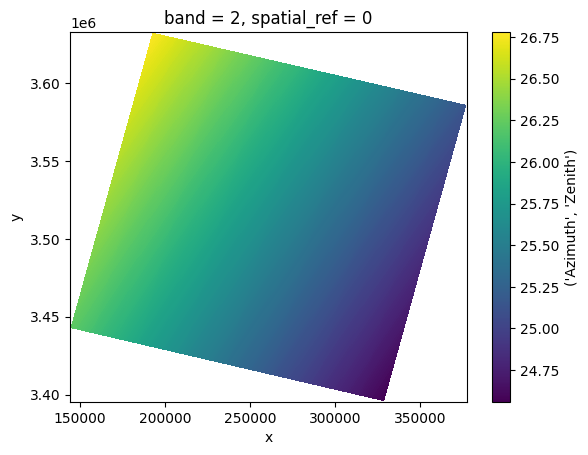

In [20]:
solar_zenith_angle.plot()

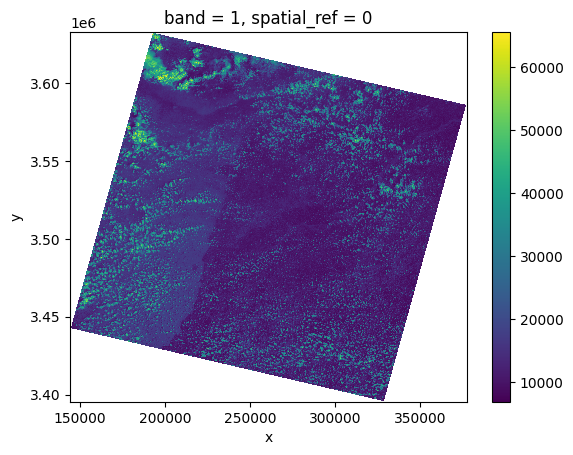

In [13]:
dn_image = dn_image.where(dn_image != no_data_value, np.nan)
dn_image.attrs['no_data_value'] = np.nan
dn_image.plot()

In [ ]:
import matplotlib.pyplot as plt

fh, ah = plt.subplots(nrows = 1,ncols = 2, figsize=(10, 4))
solar_zenith_angle.plot(ax = ah[0])
ah[0].set_title('Solar Zenith Angle [deg]')

dn_image.plot(ax = ah[1])
ah[1].set_title(f"Data Numbers (band {band})")

Text(0.5, 1.0, 'Data Numbers (band 4)')

Now, we'll compute TOA reflectance again, but this time using the pixel-wise solar angles.

In [ ]:
reflectance_b4_pw_cor = (m_lambda * dn_image + a_lambda) / np.cos(np.radians(solar_zenith_angle))
reflectance_b4_image = reflectance_b4_pw_cor.sel(band=1)

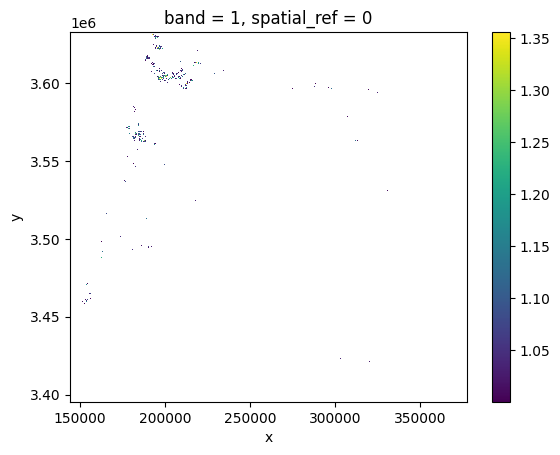

In [23]:
reflectance_b4_image.where(reflectance_b4_image > 1).plot()

In [24]:
reflectance_b4_image

<xarray.DataArray (band: 1, y: 7921, x: 7791)> Size: 494MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 62kB 1.44e+05 1.44e+05 ... 3.777e+05 3.777e+05
  * y            (y) float64 63kB 3.633e+06 3.633e+06 ... 3.395e+06 3.395e+06
    spatial_ref  int64 8B 0

Do you see any difference in the corrected image? Please explain.

Yes, but not a huge visual change. The corrected image usually looks similar in shape and pattern, but the pixel values are now reflectance instead of raw DN values, so the brightness scale is more meaningful and often a bit more balanced. Dark and bright areas may shift slightly because the image has been converted and corrected for sun angle and scene effects.

___